#1. Imports

In [101]:
import os, pickle, datetime
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import register_keras_serializable

#2. Configuration

In [102]:
MODEL_DIR    = "models"
LOG_DIR      = "logs"
DATA_DIR     = "data"

FEATURES = [
    "latitude", "longitude",
    "competitor_density_500m", "jarak_kompetitor_meter",
    "kompetitor_head_to_head",
    "cluster_hdbscan_makro", "cluster_hdbscan_prob",
    "is_hotspot",
    "density_x_headtohead", "density_per_distance",
]

TARGET           = "pelanggaran_zonasi"
EPOCHS           = 150
BATCH_SIZE       = 16
LEARNING_RATE    = 2e-4
VIOLATION_WEIGHT = 6.0
PATIENCE         = 50
TEST_SIZE        = 0.2
RANDOM_STATE     = 42
THRESHOLD        = 0.65
L2_REG           = 3e-4  # ← baru: L2 regularization

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
print("✅ Config ready")
print(f"THRESHOLD={THRESHOLD}, VIOLATION_WEIGHT={VIOLATION_WEIGHT}, PATIENCE={PATIENCE}, L2={L2_REG}")

✅ Config ready
THRESHOLD=0.65, VIOLATION_WEIGHT=6.0, PATIENCE=50, L2=0.0003


#3. Load & Validate Data

In [103]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/shineistu86/CPS-CC26/c57a4ed93bd73d13f92b8aff1c396f16b57daa7b/Data%20Clean/jaksel_spatial_features_v6_AI_ready.csv"
)
print(f"Shape: {df.shape}")
print(f"Violations: {df[TARGET].sum()} / {len(df)}")

Shape: (662, 17)
Violations: 99 / 662


#4. Feature Engineering

In [104]:
df[TARGET] = df[TARGET].astype(int)

RAW_FEATURES = [
    "latitude", "longitude", "competitor_density_500m",
    "jarak_kompetitor_meter", "kompetitor_head_to_head",
    "cluster_hdbscan_makro", "cluster_hdbscan_prob", "is_hotspot",
]
df = df.dropna(subset=RAW_FEATURES + [TARGET])

df["density_x_headtohead"] = (
    df["competitor_density_500m"] * df["kompetitor_head_to_head"]
)
df["density_per_distance"] = (
    df["competitor_density_500m"] / (df["jarak_kompetitor_meter"] + 1)
)

print(f"Rows after dropna: {len(df)}")
print(f"Class distribution: {df[TARGET].value_counts().to_dict()}")

Rows after dropna: 662
Class distribution: {0: 563, 1: 99}


#5. Correlation Check

In [105]:
corrs = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corrs = corrs.abs().sort_values(ascending=False)

print("Feature correlations with target (v3, no leakage):")
print("=" * 50)
for feat, corr in corrs.items():
    bar  = "█" * int(corr * 40)
    flag = " ⚠️ LEAKAGE" if corr > 0.5 else ""
    print(f"{feat:<30} {corr:.4f}  {bar}{flag}")

Feature correlations with target (v3, no leakage):
density_per_distance           0.1009  ████
latitude                       0.0988  ███
cluster_hdbscan_makro          0.0583  ██
kompetitor_head_to_head        0.0464  █
cluster_hdbscan_prob           0.0440  █
density_x_headtohead           0.0328  █
is_hotspot                     0.0213  
longitude                      0.0187  
jarak_kompetitor_meter         0.0054  
competitor_density_500m        0.0014  


#6. Extract X, y

In [106]:
X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)
print(f"X shape: {X.shape}")
print(f"Violation rate: {y.mean():.3f}")
print(f"Violations       : {int(y.sum())} / {len(y)}")

X shape: (662, 10)
Violation rate: 0.150
Violations       : 99 / 662


#7. Stratified Train/Test Split

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {pd.Series(y_train).value_counts().to_dict()}")
print(f"y_test : {pd.Series(y_test).value_counts().to_dict()}")

X_train: (529, 10) | X_test: (133, 10)
y_train: {0.0: 450, 1.0: 79}
y_test : {0.0: 113, 1.0: 20}


In [108]:
# ── Save split CSVs for Data Scientists (pre-SMOTE, real distribution) ──
os.makedirs(DATA_DIR, exist_ok=True)

pd.DataFrame(X_train, columns=FEATURES).assign(
    pelanggaran_zonasi=y_train
).to_csv(f"{DATA_DIR}/X_train_v3.csv", index=False)

pd.DataFrame(X_test, columns=FEATURES).assign(
    pelanggaran_zonasi=y_test
).to_csv(f"{DATA_DIR}/X_test_v3.csv", index=False)

print(f"✅ X_train_v3.csv → {len(X_train)} rows (pre-SMOTE, real distribution)")
print(f"✅ X_test_v3.csv  → {len(X_test)} rows")

✅ X_train_v3.csv → 529 rows (pre-SMOTE, real distribution)
✅ X_test_v3.csv  → 133 rows


#8: Custom Classes

In [109]:
@register_keras_serializable(package="zonify")
class SpatialDensityEmbedding(tf.keras.layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dense = tf.keras.layers.Dense(units, activation="relu")

    def build(self, input_shape):
        n_features = input_shape[-1]
        self.feature_attention = tf.keras.layers.Dense(n_features, activation="sigmoid")
        self.feature_attention.build(input_shape)
        super().build(input_shape)

    def call(self, inputs, training=False):
        attention = self.feature_attention(inputs)
        weighted  = inputs * attention
        return self.dense(weighted)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config


@register_keras_serializable(package="zonify")
def zonasi_custom_loss(y_true, y_pred):
    epsilon = 1e-7
    y_pred  = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
    bce = -(y_true * tf.math.log(y_pred) +
            (1.0 - y_true) * tf.math.log(1.0 - y_pred))
    violation_mask = tf.cast(y_true == 1, tf.float32)
    weights = 1.0 + violation_mask * VIOLATION_WEIGHT
    return tf.reduce_mean(bce * weights)


class RoundedMAE(tf.keras.metrics.Metric):
    def __init__(self, name="rounded_mae", threshold=THRESHOLD, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred >= self.threshold, tf.float32)
        mae = tf.abs(y_pred_bin - tf.cast(y_true, tf.float32))
        self.total.assign_add(tf.reduce_sum(mae))
        self.count.assign_add(tf.cast(tf.size(mae), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0)
        self.count.assign(0)

print("✅ Custom classes registered")

✅ Custom classes registered


#9. Build Model v3 + L2 Regularization

In [110]:
# ── Cell 9: build_model fn + instantiate ─────────────────────────
def build_model(input_dim: int) -> tf.keras.Model:
    reg = tf.keras.regularizers.l2(L2_REG)

    inputs = tf.keras.Input(shape=(input_dim,), name="spatial_features")
    x = SpatialDensityEmbedding(units=64, name="spatial_embedding")(inputs)
    x = tf.keras.layers.BatchNormalization(name="bn_1")(x)
    x = tf.keras.layers.Dense(128, activation="relu",
                              kernel_regularizer=reg, name="dense_1")(x)
    x = tf.keras.layers.Dropout(0.3, name="dropout_1")(x)
    x = tf.keras.layers.Dense(64, activation="relu",
                              kernel_regularizer=reg, name="dense_2")(x)
    x = tf.keras.layers.BatchNormalization(name="bn_2")(x)
    x = tf.keras.layers.Dropout(0.2, name="dropout_2")(x)
    x = tf.keras.layers.Dense(32, activation="relu",
                              kernel_regularizer=reg, name="dense_3")(x)
    output = tf.keras.layers.Dense(1, activation="sigmoid", name="violation_prob")(x)
    return tf.keras.Model(inputs=inputs, outputs=output, name="ZonifyModel_v3")

model = build_model(input_dim=len(FEATURES))   # 10 features
model.summary()
print(f"✅ Model built — input_dim={len(FEATURES)}")

Model: "ZonifyModel_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spatial_features (InputLayer)   │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_embedding               │ (None, 64)             │           814 │
│ (SpatialDensityEmbedding)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ violation_prob (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,015 (78.18 KB)

 Trainable params: 19,759 (77.18 KB)

 Non-trainable params: 256 (1.00 KB)

✅ Model built — input_dim=10


#10. Train Distribution

In [111]:
X_train_sm = X_train.astype(np.float32)
y_train_sm = y_train.astype(np.float32)

print(f"Train distribution (real): {pd.Series(y_train).value_counts().to_dict()}")
print(f"No oversampling — VIOLATION_WEIGHT={VIOLATION_WEIGHT} handles imbalance via loss")

Train distribution (real): {0.0: 450, 1.0: 79}
No oversampling — VIOLATION_WEIGHT=6.0 handles imbalance via loss


#11. Feature Scaling

In [112]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

with open(f"{MODEL_DIR}/scaler_v3.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler fitted on {X_train_sc.shape[0]} rows")

✅ Scaler fitted on 529 rows


#12. Optimizer, Metrics & Dataset Pipeline

In [113]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

train_loss_metric = tf.keras.metrics.Mean(name="train_loss")
train_acc_metric  = tf.keras.metrics.BinaryAccuracy(name="train_acc", threshold=THRESHOLD)
train_mae_metric  = RoundedMAE(name="train_mae")
val_loss_metric   = tf.keras.metrics.Mean(name="val_loss")
val_acc_metric    = tf.keras.metrics.BinaryAccuracy(name="val_acc", threshold=THRESHOLD)
val_mae_metric    = RoundedMAE(name="val_mae")

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((
        X_train_sc,
        y_train_sm.astype(np.float32)
    ))
    .shuffle(buffer_size=len(X_train_sc), seed=RANDOM_STATE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_dataset = (
    tf.data.Dataset
    .from_tensor_slices((
        X_test_sc,
        y_test.astype(np.float32)
    ))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
print(f"Train batches: {len(list(train_dataset))}")
print(f"Val   batches: {len(list(val_dataset))}")

Train batches: 34
Val   batches: 9


#13. Training Loop (tf.GradientTape)

In [114]:
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = model(x_batch, training=True)
        loss   = zonasi_custom_loss(y_batch, tf.squeeze(logits, axis=1))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y_batch, tf.squeeze(logits, axis=1))
    train_mae_metric.update_state(y_batch, tf.squeeze(logits, axis=1))

@tf.function
def val_step(x_batch, y_batch):
    logits = model(x_batch, training=False)
    loss   = zonasi_custom_loss(y_batch, tf.squeeze(logits, axis=1))
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, tf.squeeze(logits, axis=1))
    val_mae_metric.update_state(y_batch, tf.squeeze(logits, axis=1))

log_dir = f"{LOG_DIR}/zonify_v3_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
summary_writer = tf.summary.create_file_writer(log_dir)

best_val_loss  = float("inf")
patience_count = 0

header = f"{'Epoch':>7} | {'TrainLoss':>9} | {'TrainAcc':>9} | {'TrainMAE':>9} | {'ValLoss':>9} | {'ValAcc':>9} | {'ValMAE':>9}"
print(header)
print("-" * len(header))

for epoch in range(1, EPOCHS + 1):

    # ── reset at TOP of each epoch ── ← FIXED
    for m in [train_loss_metric, train_acc_metric, train_mae_metric,
              val_loss_metric,   val_acc_metric,   val_mae_metric]:
        m.reset_state()

    for xb, yb in train_dataset:
        train_step(xb, yb)
    for xb, yb in val_dataset:
        val_step(xb, yb)

    tl = train_loss_metric.result().numpy()
    ta = train_acc_metric.result().numpy()
    tm = train_mae_metric.result().numpy()
    vl = val_loss_metric.result().numpy()
    va = val_acc_metric.result().numpy()
    vm = val_mae_metric.result().numpy()

    with summary_writer.as_default():
        tf.summary.scalar("train/loss", tl, step=epoch)
        tf.summary.scalar("train/acc",  ta, step=epoch)
        tf.summary.scalar("train/mae",  tm, step=epoch)
        tf.summary.scalar("val/loss",   vl, step=epoch)
        tf.summary.scalar("val/acc",    va, step=epoch)
        tf.summary.scalar("val/mae",    vm, step=epoch)

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:>7} | {tl:>9.4f} | {ta:>9.4f} | {tm:>9.4f} | {vl:>9.4f} | {va:>9.4f} | {vm:>9.4f}")

    if vl < best_val_loss:
        best_val_loss  = vl
        patience_count = 0
        model.save(f"{MODEL_DIR}/zonify_model_v3.keras")
        print(f"         ✓ Best model saved (val_loss={vl:.4f}, val_acc={va:.4f})")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"[EARLY STOP] {PATIENCE} epochs no improvement.")
            break

  Epoch | TrainLoss |  TrainAcc |  TrainMAE |   ValLoss |    ValAcc |    ValMAE
-------------------------------------------------------------------------------
      1 |    1.7267 |    0.7637 |    0.2363 |    1.2974 |    0.8195 |    0.1805
         ✓ Best model saved (val_loss=1.2974, val_acc=0.8195)
     10 |    1.3317 |    0.7505 |    0.2495 |    1.3206 |    0.7218 |    0.2782
         ✓ Best model saved (val_loss=1.2824, val_acc=0.7218)
         ✓ Best model saved (val_loss=1.2539, val_acc=0.7218)
         ✓ Best model saved (val_loss=1.2334, val_acc=0.6992)
         ✓ Best model saved (val_loss=1.2090, val_acc=0.6992)
         ✓ Best model saved (val_loss=1.1925, val_acc=0.6992)
         ✓ Best model saved (val_loss=1.1857, val_acc=0.6767)
         ✓ Best model saved (val_loss=1.1681, val_acc=0.7218)
         ✓ Best model saved (val_loss=1.1304, val_acc=0.7594)
         ✓ Best model saved (val_loss=1.1148, val_acc=0.7519)
     20 |    1.2986 |    0.7505 |    0.2495 |    1.1073 |   

In [115]:
# ── Training Curves ───────────────────────────────────────────────
# Re-read from TensorBoard logs
import glob

history_acc   = []
history_val   = []

# Since we used tf.summary, read directly from tracked variables
# Simpler: just plot what we printed during training
# Ask: did TrainAcc increase steadily? Did ValAcc follow?

# Quick check from final epoch values
print("=== TRAINING SUMMARY ===")
print(f"Final TrainAcc : {ta:.4f}")
print(f"Final ValAcc   : {va:.4f}")
print(f"Gap (overfit?) : {ta - va:.4f}  {'⚠️ Overfitting' if ta - va > 0.15 else '✅ OK'}")
print(f"Final TrainMAE : {tm:.4f}")
print(f"Final ValMAE   : {vm:.4f}")
print()
print("Diagnosis:")
if ta < 0.80:
    print("❌ TrainAcc < 0.80 → Underfitting → increase model size or LR")
elif ta - va > 0.15:
    print("⚠️  Large train-val gap → Overfitting → increase Dropout or L2")
else:
    print("✅ Training looks healthy")

=== TRAINING SUMMARY ===
Final TrainAcc : 0.8223
Final ValAcc   : 0.7820
Gap (overfit?) : 0.0404  ✅ OK
Final TrainMAE : 0.1777
Final ValMAE   : 0.2180

Diagnosis:
✅ Training looks healthy


#14. Final Evaluation — v3 vs v2

In [116]:
# ── Load best model and evaluate ─────────────────────────────────
best_model = tf.keras.models.load_model(
    f"{MODEL_DIR}/zonify_model_v3.keras",
    custom_objects={
        "SpatialDensityEmbedding": SpatialDensityEmbedding,
        "zonasi_custom_loss"      : zonasi_custom_loss,
        "RoundedMAE"              : RoundedMAE,
    },
)

y_prob = best_model.predict(X_test_sc, verbose=0).flatten()
y_pred = (y_prob >= THRESHOLD).astype(int)

acc   = (y_pred == y_test.astype(int)).mean()
mae_r = np.abs(y_pred - y_test.astype(int)).mean()
mae_p = np.abs(y_prob - y_test).mean()
auc   = roc_auc_score(y_test, y_prob)
f1    = f1_score(y_test, y_pred)

# ── Comparison table ─────────────────────────────────────────────
print("=" * 70)
print(f"{'Metric':<20} {'v1 (leakage)':>16} {'v2 (no leak)':>16} {'v3 (final)':>16}")
print("-" * 70)
print(f"{'Accuracy':<20} {'0.9850':>16} {'0.8421':>16} {acc:>16.4f}")
print(f"{'MAE (rounded)':<20} {'0.0150':>16} {'0.1579':>16} {mae_r:>16.4f}")
print(f"{'MAE (raw prob)':<20} {'0.1921':>16} {'0.4953':>16} {mae_p:>16.4f}")
print(f"{'AUC-ROC':<20} {'0.9810':>16} {'0.4942':>16} {auc:>16.4f}")
print(f"{'F1 Score':<20} {'0.9474':>16} {'0.2222':>16} {f1:>16.4f}")
print("=" * 70)
print()
print(classification_report(y_test, y_pred, target_names=["Compliant", "Violation"]))
print(f"✅ Model saved → {MODEL_DIR}/zonify_model_v3.keras")
print(f"✅ Scaler saved → {MODEL_DIR}/scaler_v3.pkl")

Metric                   v1 (leakage)     v2 (no leak)       v3 (final)
----------------------------------------------------------------------
Accuracy                       0.9850           0.8421           0.7820
MAE (rounded)                  0.0150           0.1579           0.2180
MAE (raw prob)                 0.1921           0.4953           0.4230
AUC-ROC                        0.9810           0.4942           0.7801
F1 Score                       0.9474           0.2222           0.5085

              precision    recall  f1-score   support

   Compliant       0.95      0.79      0.86       113
   Violation       0.38      0.75      0.51        20

    accuracy                           0.78       133
   macro avg       0.67      0.77      0.68       133
weighted avg       0.86      0.78      0.81       133

✅ Model saved → models/zonify_model_v3.keras
✅ Scaler saved → models/scaler_v3.pkl


In [117]:
print("=== LEAKAGE CHECK ===")

corrs_new = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corrs_new = corrs_new.abs().sort_values(ascending=False)

print("Feature correlations with target (v3 final):")
print("=" * 55)
for feat, corr in corrs_new.items():
    bar  = "█" * int(corr * 40)
    flag = " ⚠️ POTENTIAL LEAKAGE" if corr > 0.5 else ""
    print(f"{feat:<30} {corr:.4f}  {bar}{flag}")

print()
max_corr = corrs_new.max()
if max_corr > 0.5:
    print(f"❌ Highest correlation {max_corr:.4f} > 0.50 — leakage detected")
else:
    print(f"✅ All features below 0.50 correlation — no leakage detected")
    print(f"   Highest: {corrs_new.index[0]} = {max_corr:.4f}")

=== LEAKAGE CHECK ===
Feature correlations with target (v3 final):
density_per_distance           0.1009  ████
latitude                       0.0988  ███
cluster_hdbscan_makro          0.0583  ██
kompetitor_head_to_head        0.0464  █
cluster_hdbscan_prob           0.0440  █
density_x_headtohead           0.0328  █
is_hotspot                     0.0213  
longitude                      0.0187  
jarak_kompetitor_meter         0.0054  
competitor_density_500m        0.0014  

✅ All features below 0.50 correlation — no leakage detected
   Highest: density_per_distance = 0.1009


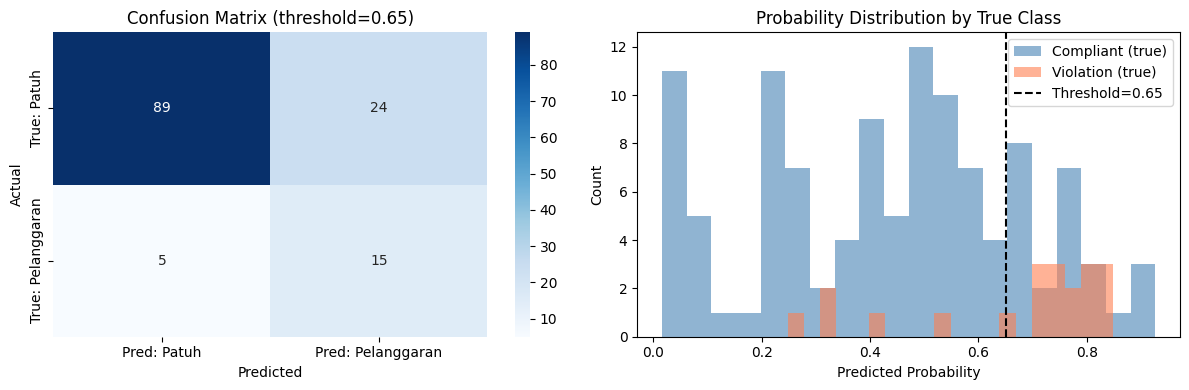

TN=89  FP=24
FN=5  TP=15
Recall (violation) : 0.7500
Precision (violation): 0.3846


In [118]:
# ── Confusion Matrix Visual ───────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

best_model = tf.keras.models.load_model(
    f"{MODEL_DIR}/zonify_model_v3.keras",
    custom_objects={
        "SpatialDensityEmbedding": SpatialDensityEmbedding,
        "zonasi_custom_loss"      : zonasi_custom_loss,
        "RoundedMAE"              : RoundedMAE,
    },
)

y_prob = best_model.predict(X_test_sc, verbose=0).flatten()
y_pred = (y_prob >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: Confusion Matrix ────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: Patuh", "Pred: Pelanggaran"],
    yticklabels=["True: Patuh", "True: Pelanggaran"],
    ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix (threshold={THRESHOLD})")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ── Right: Probability Distribution ──────────────────────────────
axes[1].hist(
    y_prob[y_test == 0], bins=20, alpha=0.6,
    color="steelblue", label="Compliant (true)"
)
axes[1].hist(
    y_prob[y_test == 1], bins=20, alpha=0.6,
    color="coral", label="Violation (true)"
)
axes[1].axvline(x=THRESHOLD, color="black", linestyle="--", label=f"Threshold={THRESHOLD}")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Probability Distribution by True Class")
axes[1].legend()

plt.tight_layout()
plt.savefig("models/confusion_and_dist.png", dpi=150)
plt.show()
print(f"TN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")
print(f"Recall (violation) : {cm[1,1] / (cm[1,0] + cm[1,1]):.4f}")
print(f"Precision (violation): {cm[1,1] / (cm[0,1] + cm[1,1]):.4f}")